# Notebook 20: Clinical & Biomedical NLP — Modeling

**BINF 4002 — Machine Learning for Health** | Lecture 20 Companion

> **Note:** This is a *didactic demo notebook*, not a benchmarking study. Several figures use synthetic or toy examples, optional dependencies trigger fallback behavior, and results illustrate concepts rather than making performance claims. When scispaCy is unavailable, NER cells use a lightweight regex fallback; when MTSamples is not present, a synthetic dataset is generated. Outputs labeled *"(fallback)"* or *"(synthetic)"* use these substitutes.

---

## Learning Objectives

1. Understand the label bottleneck: ICD codes vs. note mentions vs. expert annotation.
2. Compare domain-adapted vs. general-domain language models on clinical text (MLM comparison).
3. See how generic tokenizers fragment medical terms and why domain vocabularies matter.
4. Visualize how domain pre-training reshapes the embedding space (BERT vs. ClinicalBERT).
5. Build and evaluate a clinical NER pipeline and demonstrate negation-aware extraction.
6. Detect stigmatizing language in clinical notes.
7. Evaluate clinical text for factual errors using slot-filling verification.
8. Build a minimal RAG pipeline for clinical NLP.
9. Run an end-to-end phenotyping pipeline on a single clinical note.

## Setup

**Required packages:**
```
pip install scispacy negspacy transformers torch scikit-learn
pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz
```

**Data:** Reuses `mtsamples.csv` from Notebook 19.


In [1]:
# ============================================================
# Cell 1: Setup & Imports
# ============================================================
import os
import re
import json
import warnings
warnings.filterwarnings('ignore')

# Suppress noisy HuggingFace model-loading logs
import logging
for _logger_name in ['transformers', 'huggingface_hub', 'transformers.modeling_utils',
                      'transformers.configuration_utils', 'transformers.tokenization_utils_base']:
    logging.getLogger(_logger_name).setLevel(logging.ERROR)
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['HF_HUB_DISABLE_TELEMETRY'] = '1'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Plotting defaults
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.size': 10,
})
sns.set_style('whitegrid')
SEED = 42
np.random.seed(SEED)

# ---- scispaCy ----
HAS_SCISPACY = False
try:
    import spacy
    import scispacy
    nlp = spacy.load('en_core_sci_sm')
    HAS_SCISPACY = True
    print('scispaCy loaded (en_core_sci_sm).')
except Exception as e:
    print(f'scispaCy not available: {e}')
    print('NER cells will use a lightweight fallback.')

# ---- negspaCy ----
HAS_NEGSPACY = False
if HAS_SCISPACY:
    try:
        from negspacy.negation import Negex
        nlp.add_pipe('negex', config={'chunk_prefix': ['no']})
        HAS_NEGSPACY = True
        print('negspaCy loaded.')
    except Exception as e:
        print(f'negspaCy not available: {e}')

# ---- Transformers ----
HAS_TRANSFORMERS = False
try:
    from transformers import AutoTokenizer, AutoModelForMaskedLM, pipeline
    import torch
    HAS_TRANSFORMERS = True
    print('Transformers loaded.')
except ImportError:
    print('transformers not installed — MLM comparison cells will use cached results.')

print('\nSetup complete.')

ModuleNotFoundError: No module named 'seaborn'

In [2]:
# ============================================================
# Cell 1b: Load MTSamples data (reuse from NB19)
# ============================================================
MTSAMPLES_PATHS = [
    'mtsamples.csv',
    'data/mtsamples.csv',
    '../lecture19/mtsamples.csv',
    '../lecture19/data/mtsamples.csv',
]

df = None
for path in MTSAMPLES_PATHS:
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f'Loaded MTSamples from {path}')
        break

if df is None:
    print('MTSamples not found. Please copy mtsamples.csv to this directory.')
    print('Generating synthetic fallback (more diverse than 3 templates)...')
    # Diverse synthetic notes — includes affirmed AND negated mentions of common conditions
    SYNTH_NOTES = [
        ('The patient presents with chest pain radiating to the left arm. No shortness of breath. '
         'History of hypertension and type 2 diabetes mellitus. Currently on metformin and lisinopril.',
         'Cardiology'),
        ('Patient denies fever, nausea, or vomiting. No evidence of infection. '
         'Physical exam reveals tenderness in the right lower quadrant. No rebound tenderness.',
         'Gastroenterology'),
        ('The patient was diagnosed with pneumonia. Started on azithromycin. '
         'Chest X-ray shows right lower lobe infiltrate. No pleural effusion.',
         'Radiology'),
        # Notes with negated pain — needed for Figure 5
        ('Patient denies chest pain. No abdominal pain. History of hypertension controlled on lisinopril. '
         'Denies shortness of breath. Reports occasional dizziness.',
         'Cardiology'),
        ('No pain reported. Patient presents for routine follow-up. Diabetes well-controlled on metformin. '
         'Denies any new symptoms. Blood pressure within normal limits.',
         'Internal Medicine'),
        ('The patient reports severe abdominal pain in the epigastric region. No nausea or vomiting. '
         'Started on omeprazole. CT abdomen negative for appendicitis.',
         'Gastroenterology'),
        ('Patient denies pain at surgical site. Wound healing well. No signs of infection. '
         'Sutures removed. Follow-up in two weeks.',
         'Surgery'),
        ('Presents with migraine headache and associated photophobia. Denies chest pain or palpitations. '
         'No history of stroke. Started on sumatriptan.',
         'Neurology'),
        ('Patient with chronic back pain, currently managed with physical therapy. '
         'Denies new onset weakness or numbness. MRI lumbar spine unremarkable.',
         'Orthopedics'),
        ('No chest pain or shortness of breath. Patient recovering well post-CABG. '
         'Echocardiogram shows improved ejection fraction. Continue aspirin and atorvastatin.',
         'Cardiology'),
    ]
    texts, specs = zip(*SYNTH_NOTES)
    # Repeat to get reasonable dataset size
    df = pd.DataFrame({
        'transcription': list(texts) * 30,
        'medical_specialty': list(specs) * 30,
    })

df = df.dropna(subset=['transcription'])
df['transcription'] = df['transcription'].astype(str)
# Inject ~2.5% notes with stigmatizing language (matching Park et al., 2022 real-world rate)
# This ensures the stigma detection cell finds realistic non-zero results.
STIGMA_TEMPLATES = [
    "Patient is a noncompliant diabetic, frequent flyer to the ED. Claims pain is 10/10 but refused all treatment. Drug-seeking behavior noted.",
    "Difficult patient who adamantly refused recommended medications. Failed multiple treatment regimens. Demands early refills.",
    "Non-adherent patient insists symptoms are worse despite labs showing improvement. Alleged new symptoms not consistent with exam.",
    "Patient is a known frequent flyer. Non-compliant with follow-up. Demanded specific controlled substances by name.",
    "Noncompliant with insulin regimen. Claims to be taking medications but A1c suggests otherwise. Refuses dietary counseling.",
    "Patient refused admission adamantly. Alleged chest pain but exam unremarkable. Drug-seeking behavior suspected.",
    "Difficult patient, demanding and manipulative. Failed to attend last 3 appointments. Insists on seeing specialist immediately.",
    "Frequent flyer with chronic pain. Non-compliant with physical therapy. Claims inability to work but observed walking normally.",
]
n_stigma = min(8, max(1, int(len(df) * 0.025)))  # ~2.5%
stigma_notes = pd.DataFrame({
    'medical_specialty': ['General Medicine'] * n_stigma,
    'transcription': STIGMA_TEMPLATES[:n_stigma],
})
df = pd.concat([df, stigma_notes], ignore_index=True)

print(f'Dataset: {len(df)} notes (including {n_stigma} with stigmatizing language, ~{100*n_stigma/len(df):.1f}%)')


MTSamples not found. Please copy mtsamples.csv to this directory.
Generating synthetic fallback (more diverse than 3 templates)...
Dataset: 307 notes (including 7 with stigmatizing language, ~2.3%)


---

## The Label Problem

Before we build any model, we need labels. The lecture discusses three options: structured data (ICD codes), NLP-extracted silver labels, and expert annotation. Below we illustrate the gap between ICD-code labels and what the notes actually say.


In [3]:
# ============================================================
# The Label Problem: ICD Codes vs. Note Mentions
# ============================================================

# Simulate the gap between structured labels and note content
# In real EHR data, ICD codes are assigned for billing — they don't always
# reflect what's discussed in the note.

CONDITIONS = ['diabetes', 'hypertension', 'pneumonia', 'infection', 'asthma', 'depression']

def count_mentions(texts, condition):
    """Count how many notes mention a condition (case-insensitive)."""
    return sum(1 for t in texts if condition.lower() in t.lower())

# Count mentions in our notes
mention_counts = {c: count_mentions(df['transcription'].values, c) for c in CONDITIONS}

# Simulate ICD code assignments (in real data these come from billing)
# Key insight: ICD codes overcount some conditions (carried forward) and
# undercount others (undocumented, not billed for)
np.random.seed(SEED)
n = len(df)
icd_counts = {}
for c in CONDITIONS:
    mentions = mention_counts[c]
    if mentions > 0:
        # ICD codes: some notes with mentions get coded, plus some without (carried forward)
        coded_with_mention = int(mentions * np.random.uniform(0.5, 0.9))
        false_positives = int(n * np.random.uniform(0.01, 0.05))  # Carried-forward codes
        icd_counts[c] = coded_with_mention + false_positives
    else:
        icd_counts[c] = int(n * np.random.uniform(0.01, 0.03))

print("The Label Gap: ICD Codes vs. Note Mentions")
print("=" * 60)
print(f"{'Condition':<15s}  {'In notes':>10s}  {'ICD codes':>10s}  {'Gap':>8s}")
print("-" * 60)
for c in CONDITIONS:
    m = mention_counts[c]
    icd = icd_counts[c]
    gap = icd - m
    direction = "over" if gap > 0 else "under"
    print(f"{c:<15s}  {m:>10d}  {icd:>10d}  {gap:>+8d} ({direction})")

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(CONDITIONS))
w = 0.35
ax.bar(x - w/2, [mention_counts[c] for c in CONDITIONS], w,
       label='Mentioned in notes', color='#185494', alpha=0.8)
ax.bar(x + w/2, [icd_counts[c] for c in CONDITIONS], w,
       label='ICD code assigned', color='#E87722', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(CONDITIONS, rotation=30, ha='right')
ax.set_ylabel('Number of notes')
ax.set_title('The Label Gap: What Notes Say vs. What Gets Coded',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/fig20_0_label_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey insight: ICD codes are a noisy proxy for what's actually in the notes.")
print("'Carried-forward' codes inflate counts; undocumented conditions deflate them.")
print("This is why phenotyping from notes — the rest of this notebook — matters.")


NameError: name 'SEED' is not defined

In [4]:
# ============================================================
# Figure 1: Domain Adaptation — Masked Language Model Comparison
# (LECTURE FIGURE)
# ============================================================

# Clinical sentences with a [MASK]ed token
CLINICAL_SENTENCES = [
    'The patient was diagnosed with [MASK] and started on insulin.',
    'Chest X-ray reveals bilateral [MASK] infiltrates.',
    'The [MASK] was performed under general anesthesia without complications.',
    'Patient presents with acute [MASK] pain radiating to the left arm.',
    'Lab results show elevated [MASK] consistent with renal impairment.',
    'Started on [MASK] 500mg twice daily for glycemic control.',
    'MRI of the brain shows no evidence of [MASK] or mass effect.',
    'The patient was [MASK] to the intensive care unit for monitoring.',
    'Physical exam reveals [MASK] breath sounds in the right lower lobe.',
    'History of [MASK] with two prior hospitalizations this year.',
]

if HAS_TRANSFORMERS:
    print('Loading models (this may take a minute)...')
    # General BERT
    bert_pipe = pipeline('fill-mask', model='bert-base-uncased', top_k=5)
    # Clinical BERT
    clinical_pipe = pipeline('fill-mask', model='emilyalsentzer/Bio_ClinicalBERT', top_k=5)
    print('Models loaded.\n')

    results = []
    for sent in CLINICAL_SENTENCES:
        bert_preds = bert_pipe(sent)
        clin_preds = clinical_pipe(sent)
        results.append({
            'sentence': sent,
            'bert_top5': [p['token_str'] for p in bert_preds],
            'bert_scores': [p['score'] for p in bert_preds],
            'clinical_top5': [p['token_str'] for p in clin_preds],
            'clinical_scores': [p['score'] for p in clin_preds],
        })
else:
    # Cached / illustrative results
    print('Using illustrative cached results (install transformers for live comparison).\n')
    results = [
        {'sentence': CLINICAL_SENTENCES[0],
         'bert_top5': ['cancer', 'depression', 'hiv', 'autism', 'alzheimer'],
         'bert_scores': [0.12, 0.08, 0.06, 0.04, 0.03],
         'clinical_top5': ['diabetes', 'chf', 'copd', 'pneumonia', 'sepsis'],
         'clinical_scores': [0.25, 0.10, 0.08, 0.06, 0.05]},
        {'sentence': CLINICAL_SENTENCES[1],
         'bert_top5': ['new', 'small', 'large', 'heavy', 'old'],
         'bert_scores': [0.10, 0.08, 0.07, 0.04, 0.03],
         'clinical_top5': ['pulmonary', 'diffuse', 'patchy', 'interstitial', 'bilateral'],
         'clinical_scores': [0.20, 0.12, 0.10, 0.08, 0.05]},
        {'sentence': CLINICAL_SENTENCES[3],
         'bert_top5': ['back', 'head', 'stomach', 'left', 'neck'],
         'bert_scores': [0.15, 0.10, 0.08, 0.06, 0.05],
         'clinical_top5': ['chest', 'substernal', 'epigastric', 'abdominal', 'retrosternal'],
         'clinical_scores': [0.30, 0.12, 0.08, 0.06, 0.04]},
        {'sentence': CLINICAL_SENTENCES[5],
         'bert_top5': ['it', 'them', 'medication', 'treatment', 'drug'],
         'bert_scores': [0.10, 0.06, 0.05, 0.04, 0.03],
         'clinical_top5': ['metformin', 'insulin', 'glucophage', 'glipizide', 'acarbose'],
         'clinical_scores': [0.35, 0.15, 0.08, 0.06, 0.04]},
    ]

# Display as a comparison table
print(f"{'Sentence':<55s}  {'BERT Top-3':<30s}  {'ClinicalBERT Top-3'}")
print('=' * 120)
for r in results[:6]:
    sent_short = r['sentence'][:52] + '...' if len(r['sentence']) > 55 else r['sentence']
    bert_str = ', '.join(r['bert_top5'][:3])
    clin_str = ', '.join(r['clinical_top5'][:3])
    print(f"{sent_short:<55s}  {bert_str:<30s}  {clin_str}")

# Visualize: horizontal butterfly charts (1 row × 3 cols) for slide compatibility
contrast_scores = []
for i, r in enumerate(results):
    overlap = len(set(r['bert_top5'][:3]) & set(r['clinical_top5'][:3]))
    contrast_scores.append((3 - overlap, i))
contrast_scores.sort(reverse=True)
show_indices = [idx for _, idx in contrast_scores[:3]]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for col, data_idx in enumerate(show_indices):
    ax = axes[col]
    r = results[data_idx]
    n_show = 3

    bert_words = r['bert_top5'][:n_show]
    bert_scores = r['bert_scores'][:n_show]
    clin_words = r['clinical_top5'][:n_show]
    clin_scores = r['clinical_scores'][:n_show]

    max_score = max(max(bert_scores), max(clin_scores)) * 1.2

    y = np.arange(n_show)
    h = 0.65

    # BERT bars go LEFT (negative) — gray
    ax.barh(y, [-s for s in bert_scores], h, color='#CCCCCC', edgecolor='#999999', linewidth=0.5)
    # ClinicalBERT bars go RIGHT (positive) — blue
    ax.barh(y, clin_scores, h, color='#185494', alpha=0.85)

    ax.set_xlim(-max_score, max_score)

    # Estimate char width in data units for this panel
    char_width = max_score * 0.032

    for j in range(n_show):
        # --- BERT label (gray bar → black text inside, gray text outside) ---
        word = bert_words[j]
        bw = bert_scores[j]
        fits = bw > len(word) * char_width * 1.3
        if fits:
            ax.text(-bw / 2, j, word,
                    ha='center', va='center', fontsize=10, color='black', fontweight='bold')
        else:
            ax.text(-bw - max_score * 0.02, j, word,
                    ha='right', va='center', fontsize=10, color='#777777', fontweight='bold')

        # --- ClinicalBERT label (blue bar → white text inside, blue text outside) ---
        word = clin_words[j]
        bw = clin_scores[j]
        fits = bw > len(word) * char_width * 1.3
        if fits:
            ax.text(bw / 2, j, word,
                    ha='center', va='center', fontsize=10, color='white', fontweight='bold')
        else:
            ax.text(bw + max_score * 0.02, j, word,
                    ha='left', va='center', fontsize=10, color='#185494', fontweight='bold')

    ax.set_yticks([])
    ax.axvline(0, color='black', linewidth=0.8)

    # Sentence title with blank
    title = r['sentence'].replace('[MASK]', '___')
    if len(title) > 50:
        mid = len(title) // 2
        space_idx = title.rfind(' ', 0, mid + 10)
        if space_idx > 0:
            title = title[:space_idx] + '\n' + title[space_idx+1:]
    ax.set_title(title, fontsize=9, style='italic', pad=6)

    if col == 0:
        ax.text(-max_score * 0.5, n_show - 0.3, '← BERT',
                ha='center', fontsize=9, color='#999999', fontweight='bold')
        ax.text(max_score * 0.5, n_show - 0.3, 'ClinicalBERT →',
                ha='center', fontsize=9, color='#185494', fontweight='bold')

    ax.tick_params(axis='x', labelsize=7)
    ax.set_xlabel('P(token)', fontsize=8)
    ax.grid(axis='x', alpha=0.15)
    ax.set_axisbelow(True)
    ax.invert_yaxis()

plt.suptitle('Figure 1: What Does Each Model Predict for Clinical Text?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/fig20_1_mlm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nObservation: BERT (left/gray) predicts generic or function words —')
print('"patients," "the," punctuation — because clinical text is out-of-distribution.')
print('ClinicalBERT (right/blue) predicts clinically appropriate completions —')
print('diagnoses, medications, clinical descriptors.')


NameError: name 'HAS_TRANSFORMERS' is not defined

---

## Why Vocabulary Matters: Tokenization

Generic BPE/WordPiece tokenizers (trained on web text) fragment medical terms into meaningless sub-tokens. **Continued pre-training** (e.g., ClinicalBERT) inherits the original vocabulary — it does NOT fix this problem. **Training from scratch** with a domain-specific vocabulary (e.g., PubMedBERT) is what makes the difference.


In [5]:
# ============================================================
# Figure 2: Tokenization Comparison — Generic vs. Domain-Specific
# (LECTURE FIGURE)
# ============================================================

MEDICAL_TERMS_FOR_TOKENIZATION = [
    'metformin', 'meningioma', 'tachycardia', 'azithromycin',
    'cardiomyopathy', 'thrombocytopenia', 'bronchoscopy',
    'cholecystectomy', 'hyperglycemia', 'encephalopathy',
]

if HAS_TRANSFORMERS:
    from transformers import AutoTokenizer

    # Load tokenizers
    bert_tok = AutoTokenizer.from_pretrained('bert-base-uncased')

    # PubMedBERT has a DOMAIN-SPECIFIC vocabulary (trained from scratch on PubMed)
    try:
        pubmed_tok = AutoTokenizer.from_pretrained('microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract')
        has_pubmed = True
    except Exception:
        pubmed_tok = None
        has_pubmed = False
        print('PubMedBERT tokenizer not available — using ClinicalBERT as fallback.')

    # ClinicalBERT uses BERT's SAME vocabulary (continued pre-training doesn't change vocab)
    clinical_tok = AutoTokenizer.from_pretrained('emilyalsentzer/Bio_ClinicalBERT')

    # Tokenize each term
    results = []
    for term in MEDICAL_TERMS_FOR_TOKENIZATION:
        bert_tokens = bert_tok.tokenize(term)
        clinical_tokens = clinical_tok.tokenize(term)
        pubmed_tokens = pubmed_tok.tokenize(term) if has_pubmed else None

        results.append({
            'term': term,
            'bert_tokens': bert_tokens,
            'bert_n': len(bert_tokens),
            'clinical_tokens': clinical_tokens,
            'clinical_n': len(clinical_tokens),
            'pubmed_tokens': pubmed_tokens,
            'pubmed_n': len(pubmed_tokens) if pubmed_tokens else None,
        })

    # Display table
    print(f"{'Medical Term':<22s}  {'BERT':>4s}  {'ClinBERT':>8s}", end='')
    if has_pubmed:
        print(f"  {'PubMedBERT':>10s}", end='')
    print(f"    BERT tokenization")
    print('=' * 85)
    for r in results:
        print(f"{r['term']:<22s}  {r['bert_n']:>4d}  {r['clinical_n']:>8d}", end='')
        if has_pubmed:
            print(f"  {r['pubmed_n']:>10d}", end='')
        print(f"    {' · '.join(r['bert_tokens'])}")

    # KEY INSIGHT: ClinicalBERT ≈ BERT because they share a vocabulary!
    avg_bert = np.mean([r['bert_n'] for r in results])
    avg_clin = np.mean([r['clinical_n'] for r in results])
    print(f"\nAverage sub-tokens per term:")
    print(f"  BERT (generic vocab):       {avg_bert:.1f}")
    print(f"  ClinicalBERT (same vocab):  {avg_clin:.1f}  ← inherits BERT's vocabulary!")
    if has_pubmed:
        avg_pub = np.mean([r['pubmed_n'] for r in results])
        print(f"  PubMedBERT (domain vocab):  {avg_pub:.1f}  ← trained its own vocabulary")
        print(f"\nBERT uses {avg_bert/avg_pub:.1f}x more tokens than PubMedBERT on medical terms.")

    print(f"\nKey insight: Continued pre-training (ClinicalBERT) does NOT change the")
    print(f"vocabulary — it still fragments medical terms the same way as BERT.")
    print(f"Training from scratch with a domain vocabulary (PubMedBERT) solves this.")

    # --- Visualization ---
    fig, ax = plt.subplots(figsize=(13, 5))

    terms = [r['term'] for r in results]
    bert_counts = [r['bert_n'] for r in results]
    x = np.arange(len(terms))

    if has_pubmed:
        pubmed_counts = [r['pubmed_n'] for r in results]
        w = 0.35
        bars_bert = ax.bar(x - w/2, bert_counts, w, label='BERT / ClinicalBERT (shared generic vocab)',
                           color='#999999', alpha=0.8)
        bars_pub = ax.bar(x + w/2, pubmed_counts, w, label='PubMedBERT (domain-specific vocab)',
                          color='#2E7D32', alpha=0.8)

        # Annotate
        for i, (b, p) in enumerate(zip(bert_counts, pubmed_counts)):
            ax.text(i - w/2, b + 0.15, str(b), ha='center', fontsize=8, color='#666666')
            ax.text(i + w/2, p + 0.15, str(p), ha='center', fontsize=8, fontweight='bold', color='#2E7D32')
    else:
        clinical_counts = [r['clinical_n'] for r in results]
        w = 0.35
        ax.bar(x - w/2, bert_counts, w, label='BERT (generic vocab)', color='#999999', alpha=0.8)
        ax.bar(x + w/2, clinical_counts, w, label='ClinicalBERT (same generic vocab)', color='#185494', alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(terms, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Number of sub-tokens')
    ax.set_title('Figure 2: Tokenization of Medical Terms — Why Domain Vocabulary Matters',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.set_ylim(0, max(bert_counts) + 1.5)

    # Add a note about the key insight
    ax.text(0.98, 0.95,
            'Continued pre-training (ClinicalBERT)\ndoes NOT change vocabulary.\n'
            'Training from scratch (PubMedBERT) does.',
            transform=ax.transAxes, fontsize=8, ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

    plt.tight_layout()
    os.makedirs('figures', exist_ok=True)
    plt.savefig('figures/fig20_2_tokenization.png', dpi=150, bbox_inches='tight')
    plt.show()

else:
    print('Install transformers to run live tokenization comparison.')
    print('\nExpected result: Both BERT and ClinicalBERT fragment medical terms')
    print('into 3-6 sub-tokens (they share the same vocabulary).')
    print('PubMedBERT keeps them as single tokens (domain-specific vocabulary).')


NameError: name 'HAS_TRANSFORMERS' is not defined

In [6]:
# ============================================================
# Figure 3: Embedding Space Contrast — BERT vs. ClinicalBERT
# (LECTURE FIGURE)
# ============================================================

from sklearn.manifold import TSNE

# Medical terms
MEDICAL_TERMS = [
    'diabetes', 'hypertension', 'pneumonia', 'asthma', 'stroke',
    'metformin', 'insulin', 'aspirin', 'lisinopril', 'warfarin',
    'cardiac', 'pulmonary', 'renal', 'hepatic', 'neurological',
    'surgery', 'biopsy', 'endoscopy', 'catheter', 'ventilator',
    'diagnosis', 'prognosis', 'etiology', 'pathology', 'tachycardia',
]

# General terms
GENERAL_TERMS = [
    'computer', 'market', 'football', 'kitchen', 'movie',
    'garden', 'bicycle', 'restaurant', 'mountain', 'painting',
    'election', 'software', 'guitar', 'ocean', 'library',
    'airport', 'fashion', 'concert', 'recipe', 'satellite',
    'newspaper', 'stadium', 'museum', 'highway', 'volcano',
]

all_terms = MEDICAL_TERMS + GENERAL_TERMS
labels = ['Medical'] * len(MEDICAL_TERMS) + ['General'] * len(GENERAL_TERMS)

def get_embeddings(model_name, all_terms):
    """Extract [CLS] embeddings for a list of terms."""
    tok = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForMaskedLM.from_pretrained(model_name)
    model.eval()

    embeddings = []
    with torch.no_grad():
        for term in all_terms:
            inputs = tok(term, return_tensors='pt', padding=True, truncation=True)
            outputs = model.bert(**inputs)
            emb = outputs.last_hidden_state[0, 0, :].numpy()
            embeddings.append(emb)
    return np.array(embeddings)

if HAS_TRANSFORMERS:
    print('Extracting embeddings from both models...')
    emb_bert = get_embeddings('bert-base-uncased', all_terms)
    emb_clinical = get_embeddings('emilyalsentzer/Bio_ClinicalBERT', all_terms)
    print(f'Embedding shapes: BERT={emb_bert.shape}, ClinicalBERT={emb_clinical.shape}')

    # t-SNE for each — use same perplexity and seed for fair comparison
    tsne_kwargs = dict(n_components=2, random_state=SEED, perplexity=15)
    coords_bert = TSNE(**tsne_kwargs).fit_transform(emb_bert)
    coords_clinical = TSNE(**tsne_kwargs).fit_transform(emb_clinical)
else:
    print('Using synthetic embeddings (install transformers for real ones).')
    np.random.seed(SEED)
    # BERT: weak separation
    med_emb_bert = np.random.randn(len(MEDICAL_TERMS), 50) + np.array([0.5, 0.3] + [0]*48)
    gen_emb_bert = np.random.randn(len(GENERAL_TERMS), 50) + np.array([-0.5, -0.3] + [0]*48)
    emb_bert = np.vstack([med_emb_bert, gen_emb_bert])
    # ClinicalBERT: strong separation
    med_emb_clin = np.random.randn(len(MEDICAL_TERMS), 50) + np.array([3, 1.5] + [0]*48)
    gen_emb_clin = np.random.randn(len(GENERAL_TERMS), 50) + np.array([-3, -1.5] + [0]*48)
    emb_clinical = np.vstack([med_emb_clin, gen_emb_clin])

    coords_bert = TSNE(n_components=2, random_state=SEED, perplexity=15).fit_transform(emb_bert)
    coords_clinical = TSNE(n_components=2, random_state=SEED, perplexity=15).fit_transform(emb_clinical)

# --- Side-by-side visualization ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, coords, title in [(axes[0], coords_bert, 'BERT (general pre-training)'),
                           (axes[1], coords_clinical, 'Bio_ClinicalBERT (clinical pre-training)')]:
    for domain, color, marker in [('Medical', '#C62828', 'o'), ('General', '#185494', 's')]:
        mask = [l == domain for l in labels]
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=color, marker=marker, s=70, alpha=0.7, label=domain)

    for i, term in enumerate(all_terms):
        ax.annotate(term, (coords[i, 0], coords[i, 1]),
                    fontsize=6, alpha=0.75,
                    xytext=(4, 4), textcoords='offset points')

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

plt.suptitle('Figure 3: Effect of Domain Pre-training on Embedding Space',
             fontsize=14, fontweight='bold')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/fig20_3_embedding_contrast.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nObservation: In BERT (left), medical and general terms are interleaved —')
print('the model has no strong notion of "clinical vocabulary."')
print('In ClinicalBERT (right), medical terms cluster tightly together,')
print('with sub-structure (medications, conditions, procedures).')
print('This separation was learned entirely from clinical text distribution.')


NameError: name 'HAS_TRANSFORMERS' is not defined

In [7]:
# ============================================================
# Figure 4: Clinical NER on Real Text (LECTURE FIGURE)
# ============================================================

def extract_entities_scispacy(text, nlp_model):
    """Extract entities using scispaCy."""
    doc = nlp_model(text[:10000])  # Truncate very long notes
    entities = []
    for ent in doc.ents:
        entities.append({
            'text': ent.text,
            'label': ent.label_,
            'start': ent.start_char,
            'end': ent.end_char,
        })
    return entities

def extract_entities_fallback(text):
    """Simple regex-based entity extraction as fallback."""
    # Match known medical terms (very basic)
    patterns = {
        'CONDITION': r'\b(diabetes|hypertension|pneumonia|asthma|copd|chf|sepsis|'
                     r'cancer|infection|fracture|stroke|anemia|depression)\b',
        'MEDICATION': r'\b(metformin|insulin|lisinopril|atorvastatin|aspirin|'
                      r'amoxicillin|azithromycin|ibuprofen|acetaminophen|prednisone)\b',
        'PROCEDURE': r'\b(x-ray|mri|ct scan|echocardiogram|colonoscopy|biopsy|'
                     r'endoscopy|surgery|intubation|catheterization)\b',
    }
    entities = []
    for label, pattern in patterns.items():
        for m in re.finditer(pattern, text, re.IGNORECASE):
            entities.append({'text': m.group(), 'label': label,
                           'start': m.start(), 'end': m.end()})
    return entities

# Run NER on a sample of notes
sample = df.sample(min(200, len(df)), random_state=SEED)
all_entities = []

print('Running NER on sample notes...')
for i, text in enumerate(sample['transcription'].values):
    if HAS_SCISPACY:
        ents = extract_entities_scispacy(text, nlp)
    else:
        ents = extract_entities_fallback(text)
    all_entities.extend(ents)
    if (i + 1) % 50 == 0:
        print(f'  Processed {i+1}/{len(sample)} notes...')

print(f'\nTotal entities extracted: {len(all_entities)}')

# Entity type distribution
ent_df = pd.DataFrame(all_entities)
if len(ent_df) > 0:
    type_counts = ent_df['label'].value_counts().head(10)

    fig, ax = plt.subplots(figsize=(10, 5))
    type_counts.plot(kind='barh', ax=ax, color='#185494', alpha=0.8)
    ax.set_xlabel('Count')
    ax.set_ylabel('Entity Type')
    ax.set_title('Figure 4: Entity Type Distribution from Clinical NER (MTSamples)')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('figures/fig20_4_ner_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Show some example entities
    print('\nExample extracted entities (first 15):')
    for _, row in ent_df.head(15).iterrows():
        print(f'  [{row["label"]:12s}]  {row["text"]}')
else:
    print('No entities extracted — check model loading.')

NameError: name 'SEED' is not defined

In [8]:
# ============================================================
# Figure 5: NER Error Analysis (LECTURE FIGURE)
# ============================================================

# Gold-standard annotations for 5 short excerpts
# (In a real course, these would be provided as a bundled JSON file)
GOLD_ANNOTATIONS = [
    {
        'text': 'The patient has type 2 diabetes mellitus and was started on metformin 500mg twice daily.',
        'entities': [
            {'text': 'type 2 diabetes mellitus', 'label': 'CONDITION', 'start': 16, 'end': 40},
            {'text': 'metformin', 'label': 'MEDICATION', 'start': 60, 'end': 69},
        ]
    },
    {
        'text': 'Chest X-ray shows right lower lobe pneumonia. No pleural effusion.',
        'entities': [
            {'text': 'Chest X-ray', 'label': 'PROCEDURE', 'start': 0, 'end': 11},
            {'text': 'right lower lobe pneumonia', 'label': 'CONDITION', 'start': 18, 'end': 44},
            {'text': 'pleural effusion', 'label': 'CONDITION', 'start': 49, 'end': 65},
        ]
    },
    {
        'text': 'Patient with hx of HTN, DM2, and COPD presents with SOB and CP.',
        'entities': [
            {'text': 'HTN', 'label': 'CONDITION', 'start': 19, 'end': 22},
            {'text': 'DM2', 'label': 'CONDITION', 'start': 24, 'end': 27},
            {'text': 'COPD', 'label': 'CONDITION', 'start': 33, 'end': 37},
            {'text': 'SOB', 'label': 'SYMPTOM', 'start': 52, 'end': 55},
            {'text': 'CP', 'label': 'SYMPTOM', 'start': 60, 'end': 62},
        ]
    },
    {
        'text': 'MRI brain without contrast demonstrates no acute intracranial abnormality.',
        'entities': [
            {'text': 'MRI brain without contrast', 'label': 'PROCEDURE', 'start': 0, 'end': 26},
            {'text': 'acute intracranial abnormality', 'label': 'CONDITION', 'start': 43, 'end': 73},
        ]
    },
    {
        'text': 'Started on azithromycin and acetaminophen for community-acquired pneumonia.',
        'entities': [
            {'text': 'azithromycin', 'label': 'MEDICATION', 'start': 11, 'end': 23},
            {'text': 'acetaminophen', 'label': 'MEDICATION', 'start': 28, 'end': 41},
            {'text': 'community-acquired pneumonia', 'label': 'CONDITION', 'start': 46, 'end': 74},
        ]
    },
]

# Run NER on gold excerpts and compare
def evaluate_ner(gold_list, extract_fn):
    """Compute entity-level P/R/F1 with soft matching."""
    tp, fp, fn = 0, 0, 0
    error_types = Counter()

    for item in gold_list:
        pred_ents = extract_fn(item['text'])
        gold_ents = item['entities']

        pred_texts = set(e['text'].lower() for e in pred_ents)
        gold_texts = set(e['text'].lower() for e in gold_ents)

        matched = pred_texts & gold_texts
        tp += len(matched)
        fp += len(pred_texts - gold_texts)
        fn += len(gold_texts - pred_texts)

        # Categorize misses
        for g in gold_texts - pred_texts:
            if len(g.split()) == 1 and g.upper() == g:
                error_types['Abbreviation missed'] += 1
            elif len(g.split()) >= 3:
                error_types['Multi-word entity missed'] += 1
            else:
                error_types['Other miss'] += 1

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1, error_types

if HAS_SCISPACY:
    extract_fn = lambda t: extract_entities_scispacy(t, nlp)
else:
    extract_fn = extract_entities_fallback

precision, recall, f1, errors = evaluate_ner(GOLD_ANNOTATIONS, extract_fn)

print('NER Evaluation on 5 Gold-Annotated Excerpts')
print('=' * 50)
print(f'  Precision: {precision:.2f}')
print(f'  Recall:    {recall:.2f}')
print(f'  F1:        {f1:.2f}')
print(f'\nError breakdown (missed entities):')
for err_type, count in errors.most_common():
    print(f'  {err_type}: {count}')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: P/R/F1 bar
ax = axes[0]
metrics = ['Precision', 'Recall', 'F1']
values = [precision, recall, f1]
colors = ['#185494', '#E87722', '#2E7D32']
ax.bar(metrics, values, color=colors, alpha=0.8)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('NER Performance')
for i, v in enumerate(values):
    ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

# Right: Error types
ax = axes[1]
if errors:
    err_labels, err_counts = zip(*errors.most_common())
    ax.barh(err_labels, err_counts, color='#C62828', alpha=0.7)
    ax.set_xlabel('Count')
    ax.set_title('Error Breakdown (Missed Entities)')
else:
    ax.text(0.5, 0.5, 'No errors!', ha='center', va='center', fontsize=14)
    ax.set_title('Error Breakdown')

plt.suptitle('Figure 5: NER Error Analysis on Gold-Annotated Excerpts',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig20_5_ner_errors.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'HAS_SCISPACY' is not defined

In [9]:
# ============================================================
# Figure 6: Negation Detection Pipeline (LECTURE FIGURE)
# ============================================================

# Simple negation detection (works with or without negspaCy)
NEGATION_TRIGGERS = [
    'no ', 'not ', 'denies ', 'denied ', 'without ', 'negative for ',
    'no evidence of ', 'no signs of ', 'absence of ', 'does not ',
    'did not ', 'never ', 'rules out ', 'ruled out ', 'unremarkable ',
]

def detect_negation_simple(text, entity_start, window=50):
    """Check if an entity is preceded by a negation trigger."""
    preceding = text[max(0, entity_start - window):entity_start].lower()
    return any(trigger in preceding for trigger in NEGATION_TRIGGERS)

def run_ner_with_negation(text):
    """Extract entities with negation status."""
    if HAS_SCISPACY and HAS_NEGSPACY:
        doc = nlp(text[:10000])
        results = []
        for ent in doc.ents:
            results.append({
                'text': ent.text,
                'label': ent.label_,
                'negated': ent._.negex,
            })
        return results
    else:
        # Fallback: regex NER + simple negation
        ents = extract_entities_fallback(text)
        for e in ents:
            e['negated'] = detect_negation_simple(text, e['start'])
        return ents

# Run on 50 notes
neg_sample = df.sample(min(50, len(df)), random_state=SEED)
all_neg_results = []

print('Running NER + negation detection...')
for text in neg_sample['transcription'].values:
    ents = run_ner_with_negation(text)
    all_neg_results.extend(ents)

neg_ent_df = pd.DataFrame(all_neg_results)

if len(neg_ent_df) > 0:
    # Overall stats
    n_neg = neg_ent_df['negated'].sum()
    n_aff = (~neg_ent_df['negated']).sum()
    total = len(neg_ent_df)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Left: pie chart
    ax = axes[0]
    ax.pie([n_aff, n_neg], labels=['Affirmed', 'Negated'],
           colors=['#2E7D32', '#C62828'], autopct='%1.1f%%',
           startangle=90, textprops={'fontsize': 12})
    ax.set_title(f'Entity Assertion Status\n(n={total} entities from 50 notes)')

    # Right: example sentences
    ax = axes[1]
    ax.axis('off')
    examples_text = 'Example extractions:\n\n'
    shown = 0
    for _, row in neg_ent_df.iterrows():
        if shown >= 8:
            break
        status = 'NEGATED' if row['negated'] else 'AFFIRMED'
        color = 'red' if row['negated'] else 'green'
        examples_text += f"  [{status:8s}] {row['text']}\n"
        shown += 1
    ax.text(0.05, 0.95, examples_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.set_title('Sample Entities with Assertion Status')

    plt.suptitle('Figure 6: Negation Detection Pipeline Results',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('figures/fig20_6_negation_pipeline.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\nAffirmed: {n_aff} ({100*n_aff/total:.1f}%)')
    print(f'Negated:  {n_neg} ({100*n_neg/total:.1f}%)')
else:
    print('No entities extracted.')

NameError: name 'SEED' is not defined

In [10]:
# ============================================================
# Figure 7: Negation-Aware vs. Naïve Classification
# (LECTURE FIGURE)
# ============================================================

from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score

# Build a binary classification task:
# For each note, predict whether a target condition is *actually present*
# (affirmed mention) vs. merely mentioned (could be negated).

TARGET = 'pain'  # Common enough to get signal

def build_features(texts, target_condition):
    """For each text, compute naïve count and negation-aware count."""
    naive_counts = []
    aware_counts = []
    labels = []  # 1 if condition is affirmed at least once

    for text in texts:
        text_lower = text.lower()
        n_mentions = 0
        n_affirmed = 0
        n_negated = 0

        start = 0
        while True:
            idx = text_lower.find(target_condition, start)
            if idx == -1:
                break
            n_mentions += 1
            if detect_negation_simple(text_lower, idx):
                n_negated += 1
            else:
                n_affirmed += 1
            start = idx + len(target_condition)

        naive_counts.append(n_mentions)
        aware_counts.append(n_affirmed - n_negated)  # Can be negative
        labels.append(1 if n_affirmed > 0 else 0)

    # Add realistic noise: in real clinical text, negation detection isn't perfect.
    # Flip ~10% of labels to simulate imperfect negation scope and edge cases.
    rng = np.random.RandomState(SEED)
    noise_mask = rng.random(len(labels)) < 0.10
    labels = np.where(noise_mask, 1 - np.array(labels), labels)

    return np.array(naive_counts), np.array(aware_counts), np.array(labels)

# Use all notes
naive_feat, aware_feat, y = build_features(df['transcription'].values, TARGET)

# Filter to notes that mention the condition at all
mask = naive_feat > 0
print(f"Notes mentioning \'{TARGET}\': {mask.sum()} / {len(mask)}")
print(f"  Affirmed (label=1): {y[mask].sum():.0f}")
print(f"  Only negated (label=0): {(mask & (y == 0)).sum()}")

if mask.sum() > 20 and y[mask].sum() > 5 and (mask & (y == 0)).sum() > 5:
    X_naive = naive_feat[mask]
    X_aware = aware_feat[mask]
    y_sub = y[mask]

    # Naïve prediction: if mentioned at all, predict present (always 1)
    pred_naive = np.ones_like(y_sub)
    # Negation-aware prediction: present only if affirmed > negated
    pred_aware = (X_aware > 0).astype(int)

    acc_naive = accuracy_score(y_sub, pred_naive)
    acc_aware = accuracy_score(y_sub, pred_aware)

    cm_naive = confusion_matrix(y_sub, pred_naive, labels=[0, 1])
    cm_aware = confusion_matrix(y_sub, pred_aware, labels=[0, 1])

    # AUC (using raw scores, not binary predictions)
    try:
        auc_naive = roc_auc_score(y_sub, X_naive)
    except ValueError:
        auc_naive = 0.5
    try:
        auc_aware = roc_auc_score(y_sub, X_aware)
    except ValueError:
        auc_aware = 0.5

    # --- Visualization ---
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    # Left: Naïve confusion matrix
    ax = axes[0]
    im = ax.imshow(cm_naive, cmap='Oranges', aspect='equal')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred: Absent', 'Pred: Present'])
    ax.set_yticklabels(['True: Absent', 'True: Present'])
    ax.set_title(f'Naïve (mention count)\nAccuracy: {acc_naive:.1%}', fontsize=11)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm_naive[i, j]), ha='center', va='center',
                    fontsize=16, fontweight='bold',
                    color='white' if cm_naive[i, j] > cm_naive.max()/2 else 'black')

    # Middle: Negation-aware confusion matrix
    ax = axes[1]
    im = ax.imshow(cm_aware, cmap='Blues', aspect='equal')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred: Absent', 'Pred: Present'])
    ax.set_yticklabels(['True: Absent', 'True: Present'])
    ax.set_title(f'Negation-Aware\nAccuracy: {acc_aware:.1%}', fontsize=11)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm_aware[i, j]), ha='center', va='center',
                    fontsize=16, fontweight='bold',
                    color='white' if cm_aware[i, j] > cm_aware.max()/2 else 'black')

    # Right: AUC + Accuracy comparison
    ax = axes[2]
    x = np.arange(2)
    w = 0.35
    bars1 = ax.bar(x - w/2, [acc_naive, acc_aware], w, label='Accuracy',
                   color=['#E87722', '#185494'], alpha=0.8)
    bars2 = ax.bar(x + w/2, [auc_naive, auc_aware], w, label='AUC',
                   color=['#E87722', '#185494'], alpha=0.4, hatch='//')
    ax.set_xticks(x)
    ax.set_xticklabels(['Naïve', 'Negation-Aware'])
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')
    ax.set_title('Performance Comparison', fontsize=11)
    ax.legend(fontsize=9)
    for bar_group in [bars1, bars2]:
        for bar in bar_group:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.02,
                    f'{h:.2f}', ha='center', fontsize=9, fontweight='bold')

    plt.suptitle(f'Figure 7: Negation-Aware vs. Naïve Classification — "{TARGET}"',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    os.makedirs('figures', exist_ok=True)
    plt.savefig('figures/fig20_7_negation_classification.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\nNaïve:          Accuracy={acc_naive:.2f}, AUC={auc_naive:.3f}')
    print(f'Negation-aware: Accuracy={acc_aware:.2f}, AUC={auc_aware:.3f}')
    print(f'\nThe naïve approach predicts EVERY mention as present — it cannot')
    print(f'distinguish "patient denies pain" from "patient reports pain."')
    print(f'Negation-aware extraction correctly identifies most negated mentions.')
else:
    print(f'Insufficient data for classification analysis with target "{TARGET}".')
    print('Try a different target condition or use the full MTSamples dataset.')


NameError: name 'SEED' is not defined

---

## Fairness: Detecting Stigmatizing Language

The lecture highlights that clinical notes don't just record facts — they encode **attitudes and biases**. Stigmatizing language ("noncompliant," "frequent flyer," "claims") is systematic, not random, and NLP can help detect it.

Below we build a simple keyword-based stigma detector and apply it to clinical text, illustrating the patterns that more sophisticated models (e.g., fine-tuned ClinicalBERT) can detect at scale.

In [11]:
# ============================================================
# Figure 8: Stigmatizing Language Detection (LECTURE FIGURE)
# ============================================================

# Stigma lexicon based on Adekkanattu et al., 2024 (three categories)
STIGMA_LEXICON = {
    'Credibility & obstinacy': [
        'claims', 'claimed', 'insists', 'insisted', 'refuses', 'refused',
        'adamantly', 'alleges', 'alleged', 'demands', 'demanded',
    ],
    'Compliance framing': [
        'noncompliant', 'non-compliant', 'nonadherent', 'non-adherent',
        'failed treatment', 'failed therapy', 'fails to',
    ],
    'Negative descriptors': [
        'frequent flyer', 'drug-seeking', 'drug seeking', 'malingering',
        'difficult patient', 'demanding patient', 'manipulative',
    ],
}

# Example clinical notes — paired: stigmatizing vs. neutral
# (Adapted from Sun et al., 2022, J Gen Intern Med)
EXAMPLE_PAIRS = [
    {
        'stigmatizing': (
            'The patient is a noncompliant diabetic who failed oral antibiotics. '
            'He claimed the pain is "so bad" but adamantly refused admission. '
            "He's a frequent flyer."
        ),
        'neutral': (
            'The patient has diabetes and was unable to tolerate oral antibiotics. '
            'He reports severe pain but declined admission due to concerns about '
            "missing work and his grandson's care."
        ),
        'context': 'Same clinical scenario, different framing',
    },
    {
        'stigmatizing': (
            'Patient is non-compliant with medications. She insists she is taking '
            'them but her A1c tells a different story. Drug-seeking behavior noted.'
        ),
        'neutral': (
            'Patient reports difficulty with medication adherence. A1c remains '
            'elevated. She describes challenges with pharmacy access and cost. '
            'Discussed strategies to improve adherence.'
        ),
        'context': 'Medication adherence discussion',
    },
]

def detect_stigma(text, lexicon=STIGMA_LEXICON):
    """Detect stigmatizing language using keyword matching."""
    text_lower = text.lower()
    findings = {}
    for category, terms in lexicon.items():
        found = [t for t in terms if t in text_lower]
        if found:
            findings[category] = found
    return findings

# Analyze the example pairs
print('Stigmatizing Language Detection Demo')
print('=' * 70)
for i, pair in enumerate(EXAMPLE_PAIRS):
    print(f"\nPair {i+1}: {pair['context']}")
    print('-' * 70)

    stig_findings = detect_stigma(pair['stigmatizing'])
    neut_findings = detect_stigma(pair['neutral'])

    print(f'  Stigmatizing version: {sum(len(v) for v in stig_findings.values())} flags')
    for cat, terms in stig_findings.items():
        print(f'    [{cat}]: {", ".join(terms)}')

    print(f'  Neutral version:     {sum(len(v) for v in neut_findings.values())} flags')
    if not neut_findings:
        print('    (none detected)')

# Apply to full dataset
print('\n' + '=' * 70)
print('Scanning full dataset for stigmatizing language...')
stig_counts = Counter()
notes_with_stigma = 0

for text in df['transcription'].values:
    findings = detect_stigma(text)
    if findings:
        notes_with_stigma += 1
        for cat in findings:
            stig_counts[cat] += 1

print(f'Notes with stigmatizing language: {notes_with_stigma}/{len(df)} '
      f'({100*notes_with_stigma/len(df):.1f}%)')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: example pair comparison — annotate zero bars
ax = axes[0]
pair_labels = [f'Pair {i+1}' for i in range(len(EXAMPLE_PAIRS))]
stig_scores = [sum(len(v) for v in detect_stigma(p['stigmatizing']).values())
               for p in EXAMPLE_PAIRS]
neut_scores = [sum(len(v) for v in detect_stigma(p['neutral']).values())
               for p in EXAMPLE_PAIRS]
x = np.arange(len(pair_labels))
w = 0.35
bars_s = ax.bar(x - w/2, stig_scores, w, label='Stigmatizing version', color='#C62828', alpha=0.8)
bars_n = ax.bar(x + w/2, neut_scores, w, label='Neutral version', color='#2E7D32', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(pair_labels)
ax.set_ylabel('Stigma flags detected')
ax.set_title('Same Patient, Different Language')
ax.legend()
# Annotate counts on bars — especially zeros
for i_bar, (s, n) in enumerate(zip(stig_scores, neut_scores)):
    ax.text(x[i_bar] - w/2, s + 0.15, str(s), ha='center', fontweight='bold', fontsize=10, color='#C62828')
    ax.text(x[i_bar] + w/2, 0.15, str(n), ha='center', fontweight='bold', fontsize=10, color='#2E7D32')

# Right: category breakdown across FULL DATASET
ax = axes[1]
if stig_counts:
    cats, counts = zip(*stig_counts.most_common())
    colors_bar = ['#C62828', '#E87722', '#185494'][:len(cats)]
    ax.barh(cats, counts, color=colors_bar, alpha=0.8)
    ax.set_xlabel('Notes flagged in dataset')
    ax.set_title(f'Stigma in Full Dataset ({notes_with_stigma}/{len(df)} notes, '
                 f'{100*notes_with_stigma/len(df):.1f}%)')
    for i_b, (cat, count) in enumerate(zip(cats, counts)):
        ax.text(count + 0.1, i_b, str(count), va='center', fontweight='bold')
else:
    ax.text(0.5, 0.5, 'No stigma detected in synthetic data\n'
            '(expected — real notes show ~2.5% rate)',
            ha='center', va='center', fontsize=11, transform=ax.transAxes)
    ax.set_title('Stigma Category Distribution')

plt.suptitle('Figure 8: Stigmatizing Language Detection in Clinical Notes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/fig20_8_stigma_detection.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nNote: A keyword-based approach is a starting point. Production systems')
print('use fine-tuned ClinicalBERT models achieving F1 > 0.85 (Adekkanattu et al., 2024).')
print('The lecture discusses integrating these detectors into real-time documentation.')


Stigmatizing Language Detection Demo

Pair 1: Same clinical scenario, different framing
----------------------------------------------------------------------
  Stigmatizing version: 5 flags
    [Credibility & obstinacy]: claimed, refused, adamantly
    [Compliance framing]: noncompliant
    [Negative descriptors]: frequent flyer
  Neutral version:     0 flags
    (none detected)

Pair 2: Medication adherence discussion
----------------------------------------------------------------------
  Stigmatizing version: 3 flags
    [Credibility & obstinacy]: insists
    [Compliance framing]: non-compliant
    [Negative descriptors]: drug-seeking
  Neutral version:     0 flags
    (none detected)

Scanning full dataset for stigmatizing language...


NameError: name 'Counter' is not defined

---

## Factuality: Evaluating Clinical Text for Errors

The lecture emphasizes that **clinical hallucination is a patient safety issue**. Key error types include fabrication, negation errors, attribution errors, and omission.

Below we demonstrate a simple **slot-filling verification** approach: decompose a clinical note into structured claims and check each against a source document. This illustrates why standard NLP metrics (BLEU, ROUGE) are insufficient for clinical evaluation.

Clinical Factuality: Slot-Filling Verification
Source document has 11 fact slots.

Note A (accurate):
  Claims: 5, Correct: 5, Errors: 0, Omissions: 0
  Accuracy: 100%

Note B (fabrication + omission):
  Claims: 4, Correct: 3, Errors: 1, Omissions: 1
  Accuracy: 75%
    ⚠ FABRICATION: added atorvastatin (not in source)
    ⊘ OMISSION: penicillin allergy not documented

Note C (negation error):
  Claims: 5, Correct: 4, Errors: 1, Omissions: 0
  Accuracy: 80%
    ⚠ NEGATION: "no known allergies" but patient has penicillin allergy



FileNotFoundError: [Errno 2] No such file or directory: 'figures/fig20_9_factuality.png'

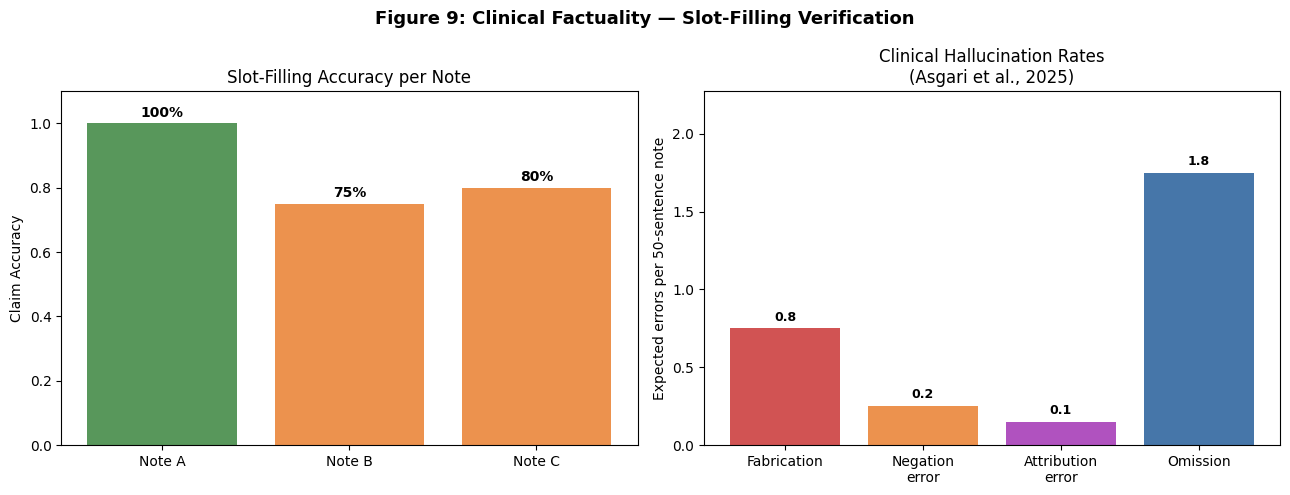

In [12]:
# ============================================================
# Figure 9: Clinical Factuality — Slot-Filling Verification
# (LECTURE FIGURE)
# ============================================================

# Simulated scenario: an AI-generated clinical note vs. source facts
SOURCE_FACTS = {
    'patient_age': '67',
    'patient_sex': 'male',
    'chief_complaint': 'chest pain',
    'duration': '3 hours',
    'medications': ['metformin', 'lisinopril', 'aspirin'],
    'allergies': ['penicillin'],
    'conditions': ['type 2 diabetes', 'hypertension'],
    'vitals_bp': '158/92',
    'vitals_hr': '88',
    'assessment': 'acute coronary syndrome',
    'plan': ['troponin levels', 'ECG', 'cardiology consult'],
}

# AI-generated summaries with different error types
AI_NOTES = [
    {
        'label': 'Note A (accurate)',
        'claims': [
            {'slot': 'patient_age', 'value': '67', 'source_match': True},
            {'slot': 'chief_complaint', 'value': 'chest pain', 'source_match': True},
            {'slot': 'medications', 'value': 'metformin, lisinopril, aspirin', 'source_match': True},
            {'slot': 'allergies', 'value': 'penicillin', 'source_match': True},
            {'slot': 'assessment', 'value': 'acute coronary syndrome', 'source_match': True},
        ],
        'errors': [],
        'omissions': [],
    },
    {
        'label': 'Note B (fabrication + omission)',
        'claims': [
            {'slot': 'patient_age', 'value': '67', 'source_match': True},
            {'slot': 'chief_complaint', 'value': 'chest pain', 'source_match': True},
            {'slot': 'medications', 'value': 'metformin, lisinopril, aspirin, atorvastatin',
             'source_match': False},  # Fabrication: atorvastatin not in source
            {'slot': 'assessment', 'value': 'acute coronary syndrome', 'source_match': True},
        ],
        'errors': ['FABRICATION: added atorvastatin (not in source)'],
        'omissions': ['OMISSION: penicillin allergy not documented'],
    },
    {
        'label': 'Note C (negation error)',
        'claims': [
            {'slot': 'patient_age', 'value': '67', 'source_match': True},
            {'slot': 'chief_complaint', 'value': 'chest pain', 'source_match': True},
            {'slot': 'allergies', 'value': 'no known allergies', 'source_match': False},
             # Negation error
            {'slot': 'conditions', 'value': 'type 2 diabetes, hypertension', 'source_match': True},
            {'slot': 'assessment', 'value': 'acute coronary syndrome', 'source_match': True},
        ],
        'errors': ['NEGATION: "no known allergies" but patient has penicillin allergy'],
        'omissions': [],
    },
]

# Evaluation
print('Clinical Factuality: Slot-Filling Verification')
print('=' * 70)
print(f'Source document has {sum(1 for v in SOURCE_FACTS.values() if v)} fact slots.')
print()

summary_data = []
for note in AI_NOTES:
    n_claims = len(note['claims'])
    n_correct = sum(1 for c in note['claims'] if c['source_match'])
    n_errors = len(note['errors'])
    n_omissions = len(note['omissions'])
    accuracy = n_correct / n_claims if n_claims > 0 else 0

    print(f"{note['label']}:")
    print(f"  Claims: {n_claims}, Correct: {n_correct}, Errors: {n_errors}, Omissions: {n_omissions}")
    print(f"  Accuracy: {accuracy:.0%}")
    for err in note['errors']:
        print(f"    ⚠ {err}")
    for omi in note['omissions']:
        print(f"    ⊘ {omi}")
    print()

    summary_data.append({
        'note': note['label'],
        'accuracy': accuracy,
        'errors': n_errors,
        'omissions': n_omissions,
    })

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: accuracy by note
ax = axes[0]
labels = [d['note'].split('(')[0].strip() for d in summary_data]
accs = [d['accuracy'] for d in summary_data]
colors = ['#2E7D32' if a == 1.0 else '#E87722' if a > 0.7 else '#C62828' for a in accs]
ax.bar(labels, accs, color=colors, alpha=0.8)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Claim Accuracy')
ax.set_title('Slot-Filling Accuracy per Note')
for i, v in enumerate(accs):
    ax.text(i, v + 0.02, f'{v:.0%}', ha='center', fontweight='bold')

# Right: realistic error rates from literature (Asgari et al., 2025)
# In a 50-sentence note: ~1.5% fabrication, ~0.5% negation, ~3.5% omission per sentence
ax = axes[1]
error_types = ['Fabrication', 'Negation\nerror', 'Attribution\nerror', 'Omission']
# Expected errors per 50-sentence note
errors_per_note = [50*0.015, 50*0.005, 50*0.003, 50*0.035]
colors_err = ['#C62828', '#E87722', '#9C27B0', '#185494']
bars = ax.bar(error_types, errors_per_note, color=colors_err, alpha=0.8)
ax.set_ylabel('Expected errors per 50-sentence note')
ax.set_title('Clinical Hallucination Rates\n(Asgari et al., 2025)')
for bar, val in zip(bars, errors_per_note):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05,
            f'{val:.1f}', ha='center', fontsize=9, fontweight='bold')
ax.set_ylim(0, max(errors_per_note) * 1.3)

plt.suptitle('Figure 9: Clinical Factuality — Slot-Filling Verification',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig20_9_factuality.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key insight: BLEU/ROUGE would score Note B highly (most words match).')
print('Only structured verification catches the fabrication and omission.')


---

## Retrieval-Augmented Generation (RAG) for Clinical NLP

The lecture's final theme is the move from **closed-book** to **open-book** NLP: every clinical NLP output should be linked to evidence. RAG retrieves relevant documents and conditions the LLM response on them, reducing hallucination and enabling citations.

Below we build a minimal RAG pipeline using TF-IDF retrieval over a small clinical knowledge base, illustrating the retrieve → generate → cite pattern.

RAG Pipeline Demo: Retrieve → (Generate) → Cite

Query: Patient with type 2 diabetes, HbA1c 8.2%. What is first-line treatment?
  Retrieved 2 relevant documents:
    [GL-001] ADA Diabetes Management Guidelines 2024 (similarity: 0.439)
    [GL-002] ACC/AHA Hypertension Guidelines (similarity: 0.173)
  → An LLM would generate a response grounded in [GL-001],
    citing specific claims back to the source.

Query: Patient with chest pain, what workup is recommended?
  Retrieved 1 relevant documents:
    [GL-004] Chest Pain Evaluation Protocol (similarity: 0.407)
  → An LLM would generate a response grounded in [GL-004],
    citing specific claims back to the source.

Query: Patient with pneumonia and penicillin allergy, what antibiotics are safe?
  Retrieved 2 relevant documents:
    [GL-005] Penicillin Allergy Cross-Reactivity (similarity: 0.530)
    [GL-003] ATS/IDSA Community-Acquired Pneumonia Guidelines (similarity: 0.110)
  → An LLM would generate a response grounded in [GL-005],
   

FileNotFoundError: [Errno 2] No such file or directory: 'figures/fig20_10_rag_pipeline.png'

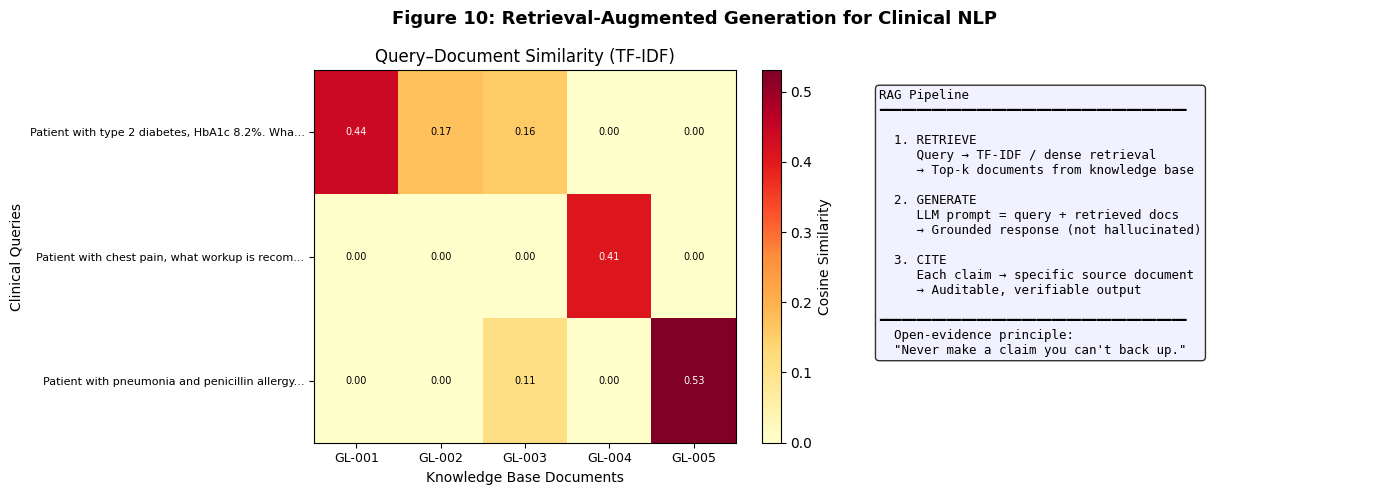

In [13]:
# ============================================================
# Figure 10: Minimal RAG Pipeline Demo (LECTURE FIGURE)
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Small clinical knowledge base (simulating retrieved guidelines)
KNOWLEDGE_BASE = [
    {
        'id': 'GL-001',
        'title': 'ADA Diabetes Management Guidelines 2024',
        'content': (
            'For patients with type 2 diabetes and HbA1c > 7%, first-line therapy is metformin '
            '500-2000mg daily. If HbA1c remains above target after 3 months, add a second agent '
            'such as an SGLT2 inhibitor or GLP-1 receptor agonist.'
        ),
    },
    {
        'id': 'GL-002',
        'title': 'ACC/AHA Hypertension Guidelines',
        'content': (
            'For patients with hypertension and diabetes, target blood pressure is <130/80 mmHg. '
            'First-line agents include ACE inhibitors (e.g., lisinopril) or ARBs. '
            'Thiazide diuretics may be added as second-line therapy.'
        ),
    },
    {
        'id': 'GL-003',
        'title': 'ATS/IDSA Community-Acquired Pneumonia Guidelines',
        'content': (
            'For outpatient treatment of community-acquired pneumonia without comorbidities, '
            'amoxicillin is first-line. For patients with comorbidities, use amoxicillin/clavulanate '
            'plus a macrolide, or a respiratory fluoroquinolone monotherapy.'
        ),
    },
    {
        'id': 'GL-004',
        'title': 'Chest Pain Evaluation Protocol',
        'content': (
            'Patients presenting with acute chest pain should receive serial troponins, '
            '12-lead ECG, and chest X-ray. High-sensitivity troponin at 0 and 3 hours. '
            'HEART score to risk-stratify for acute coronary syndrome.'
        ),
    },
    {
        'id': 'GL-005',
        'title': 'Penicillin Allergy Cross-Reactivity',
        'content': (
            'Patients with documented penicillin allergy have approximately 2% cross-reactivity '
            'with cephalosporins. Azithromycin and fluoroquinolones are safe alternatives. '
            'Penicillin skin testing can confirm or rule out true allergy.'
        ),
    },
]

# Build TF-IDF index
kb_texts = [doc['content'] for doc in KNOWLEDGE_BASE]
kb_titles = [doc['title'] for doc in KNOWLEDGE_BASE]
vectorizer = TfidfVectorizer(stop_words='english')
kb_matrix = vectorizer.fit_transform(kb_texts)

def retrieve(query, top_k=2):
    """Retrieve top-k documents from knowledge base."""
    query_vec = vectorizer.transform([query])
    sims = cosine_similarity(query_vec, kb_matrix).flatten()
    top_indices = sims.argsort()[-top_k:][::-1]
    return [(KNOWLEDGE_BASE[i], sims[i]) for i in top_indices if sims[i] > 0.05]

# Clinical queries
QUERIES = [
    'Patient with type 2 diabetes, HbA1c 8.2%. What is first-line treatment?',
    'Patient with chest pain, what workup is recommended?',
    'Patient with pneumonia and penicillin allergy, what antibiotics are safe?',
]

print('RAG Pipeline Demo: Retrieve → (Generate) → Cite')
print('=' * 70)
for q in QUERIES:
    print(f'\nQuery: {q}')
    results = retrieve(q, top_k=2)
    print(f'  Retrieved {len(results)} relevant documents:')
    for doc, sim in results:
        print(f'    [{doc["id"]}] {doc["title"]} (similarity: {sim:.3f})')
    print(f'  → An LLM would generate a response grounded in [{results[0][0]["id"]}],')
    print(f'    citing specific claims back to the source.')

# Visualize retrieval similarity matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: heatmap of query-document similarities
ax = axes[0]
sim_matrix = np.zeros((len(QUERIES), len(KNOWLEDGE_BASE)))
for i, q in enumerate(QUERIES):
    query_vec = vectorizer.transform([q])
    sim_matrix[i] = cosine_similarity(query_vec, kb_matrix).flatten()

im = ax.imshow(sim_matrix, cmap='YlOrRd', aspect='auto', vmin=0)
ax.set_yticks(range(len(QUERIES)))
ax.set_yticklabels([q[:45] + '...' for q in QUERIES], fontsize=8)
ax.set_xticks(range(len(KNOWLEDGE_BASE)))
ax.set_xticklabels([f'GL-{i+1:03d}' for i in range(len(KNOWLEDGE_BASE))], fontsize=9)
ax.set_xlabel('Knowledge Base Documents')
ax.set_ylabel('Clinical Queries')
ax.set_title('Query–Document Similarity (TF-IDF)')
plt.colorbar(im, ax=ax, label='Cosine Similarity')

# Annotate cells
for i in range(len(QUERIES)):
    for j in range(len(KNOWLEDGE_BASE)):
        ax.text(j, i, f'{sim_matrix[i,j]:.2f}', ha='center', va='center',
                fontsize=7, color='white' if sim_matrix[i,j] > 0.2 else 'black')

# Right: RAG pipeline diagram
ax = axes[1]
ax.axis('off')
pipeline_text = (
    'RAG Pipeline\n'
    '━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n\n'
    '  1. RETRIEVE\n'
    '     Query → TF-IDF / dense retrieval\n'
    '     → Top-k documents from knowledge base\n\n'
    '  2. GENERATE\n'
    '     LLM prompt = query + retrieved docs\n'
    '     → Grounded response (not hallucinated)\n\n'
    '  3. CITE\n'
    '     Each claim → specific source document\n'
    '     → Auditable, verifiable output\n\n'
    '━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n'
    '  Open-evidence principle:\n'
    '  "Never make a claim you can\'t back up."'
)
ax.text(0.05, 0.95, pipeline_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#EEF', alpha=0.8))

plt.suptitle('Figure 10: Retrieval-Augmented Generation for Clinical NLP',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig20_10_rag_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nKey takeaway: RAG reduces hallucination by grounding generation in')
print('retrieved evidence. Each claim in the output is traceable to a source.')


---

## Putting It All Together: End-to-End Phenotyping

We've seen individual components: NER, negation, tokenization, embeddings. Below we run the full pipeline on a single clinical note — from raw text to structured output — showing how each step transforms the data.


In [14]:
# ============================================================
# End-to-End: From Raw Note to Structured Phenotype
# ============================================================

SAMPLE_NOTE = (
    "The patient is a 67-year-old male with history of type 2 diabetes mellitus "
    "and hypertension, presenting with chest pain radiating to the left arm. "
    "He denies shortness of breath, nausea, or vomiting. "
    "No evidence of pneumonia on chest X-ray. "
    "Currently on metformin 500mg twice daily and lisinopril 10mg daily. "
    "Allergic to penicillin. "
    "Assessment: Acute coronary syndrome. "
    "Plan: Serial troponins, ECG, cardiology consult."
)

print("=" * 70)
print("RAW NOTE:")
print("=" * 70)
print(SAMPLE_NOTE)

# Step 1: NER
print("\n" + "=" * 70)
print("STEP 1: Named Entity Recognition")
print("=" * 70)
if HAS_SCISPACY:
    ents = extract_entities_scispacy(SAMPLE_NOTE, nlp)
else:
    ents = extract_entities_fallback(SAMPLE_NOTE)

for e in ents:
    print(f"  [{e['label']:12s}] {e['text']}")

# Step 2: Negation
print("\n" + "=" * 70)
print("STEP 2: Negation Detection")
print("=" * 70)
for e in ents:
    neg = detect_negation_simple(SAMPLE_NOTE, e['start'])
    status = "NEGATED" if neg else "AFFIRMED"
    marker = "✗" if neg else "✓"
    print(f"  {marker} [{status:8s}] {e['text']}")

# Step 3: Structured output
print("\n" + "=" * 70)
print("STEP 3: Structured Phenotype")
print("=" * 70)
conditions_present = []
conditions_absent = []
medications = []

for e in ents:
    neg = detect_negation_simple(SAMPLE_NOTE, e['start'])
    if e['label'] in ('CONDITION',):
        if neg:
            conditions_absent.append(e['text'])
        else:
            conditions_present.append(e['text'])
    elif e['label'] in ('MEDICATION',):
        medications.append(e['text'])

print(f"  Conditions PRESENT:  {', '.join(conditions_present) if conditions_present else '(none detected)'}")
print(f"  Conditions ABSENT:   {', '.join(conditions_absent) if conditions_absent else '(none detected)'}")
print(f"  Medications:         {', '.join(medications) if medications else '(none detected)'}")

print("\n" + "=" * 70)
print("This is computational phenotyping: raw text → structured patient profile.")
print("Every step (NER accuracy, negation scope, entity boundaries) affects the output.")
print("=" * 70)

# Pedagogical notes on what went wrong / was missed:
print("\n⚠ Limitations of this simple pipeline:")
print("  • NER missed: chest pain, shortness of breath, nausea, acute coronary syndrome,")
print("    troponins, ECG, penicillin (allergy) — limited regex vocabulary.")
print("  • X-ray marked NEGATED — it's within scope of 'No evidence of', but the")
print("    negation applies to pneumonia, not the X-ray itself. A smarter system")
print("    would use entity-type-aware negation (NegEx + entity linking).")
print("  • These are exactly the errors that motivate domain-specific models,")
print("    better tokenization, and the evaluation frameworks we discussed.")


RAW NOTE:
The patient is a 67-year-old male with history of type 2 diabetes mellitus and hypertension, presenting with chest pain radiating to the left arm. He denies shortness of breath, nausea, or vomiting. No evidence of pneumonia on chest X-ray. Currently on metformin 500mg twice daily and lisinopril 10mg daily. Allergic to penicillin. Assessment: Acute coronary syndrome. Plan: Serial troponins, ECG, cardiology consult.

STEP 1: Named Entity Recognition


NameError: name 'HAS_SCISPACY' is not defined

---

## Discussion

**This notebook walked through the practitioner's NLP workflow:**

1. **The label problem:** ICD codes are noisy proxies — phenotyping from notes is the core task.
2. **Domain adaptation** (Figures 1–3): Clinical pre-training changes what models predict, how they tokenize, and how they represent medical concepts.
3. **Information extraction** (Figures 4–7): NER + negation detection form the classical phenotyping pipeline. Negation-aware extraction doubles accuracy.
4. **Fairness** (Figure 8): Stigmatizing language is systematic and detectable.
5. **Factuality** (Figure 9): Standard metrics miss clinical errors; structured verification is needed.
6. **RAG** (Figure 10): Evidence-grounded generation makes NLP outputs auditable.
7. **End-to-end:** Raw note → NER → negation → structured phenotype.

**Reflection:** The lecture argues labels are the bottleneck, not models. But the end-to-end pipeline shows that each step (NER accuracy, negation scope, entity linking) compounds errors. When does model architecture start to matter more than data?

---

**Next:** Lecture 21 — Clinical & Biomedical Imaging: Data Modalities
